# Explorare Dataset ZuCo 2.0 - Analiza Eye-Tracking si Comparativa EEG
**Autor:** Persoana 2

Acest notebook exploreaza dataset-ul ZuCo 2.0. ZuCo 2.0 introduce 2 task-uri noi (Normal Reading si Annotation) si adauga date de eye-tracking sincronizate cu semnalul EEG. Scopul final este sa determinam care dataset si care task sunt mai potrivite pentru antrenarea modelului de EEG-to-Text.

In [2]:
import numpy as np
import scipy.io
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import mne
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid")

## Pasul 1: Incarcare si Comparatie Structurala
In aceasta sectiune incarcam datele ZuCo 2.0 din fisierele .mat locale si le comparam teoretic cu ZuCo 1.0. Vom analiza structura: numarul de canale, subiecti, taskuri si vocabularul.

In [6]:
# Functie pentru incarcarea datelor folosind h5py (format .mat v7.3)
def load_zuco_data(filepath):
    try:
        data = h5py.File(filepath, 'r')
        return data
    except Exception as e:
        print(f"Eroare la incarcare {filepath}: {e}")
        return None

base_path = "C:/Users/Caius/Downloads/"

fisiere_nr = [
    "resultsYDR_NR.mat", "resultsYFS_NR.mat",
    "resultsYHS_NR.mat", "resultsYAK_NR.mat",
    "resultsYAC_NR.mat"
]

fisiere_tsr = [
    "resultsYDR_TSR.mat", "resultsYFS_TSR.mat",
    "resultsYHS_TSR.mat", "resultsYAC_TSR.mat",
    "resultsYIS_TSR.mat"
]

print(f"Incarcam fisierul de test: {fisiere_nr[0]}")
data_test = load_zuco_data(base_path + fisiere_nr[0])
if data_test:
    print("Fisier incarcat cu succes! Chei disponibile:", list(data_test.keys()))

# Tabel comparativ ZuCo 1.0 vs ZuCo 2.0
comparison_data = {
    "Aspect": ["Subiecti", "Task-uri", "Eye-tracking", "Frecventa esantionare"],
    "ZuCo 1.0": ["18", "Citire recenzii/Wikipedia", "Nu", "500 Hz"],
    "ZuCo 2.0": ["18", "Normal Reading / Annotation", "Da", "500 Hz"]
}
df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)


Incarcam fisierul de test: resultsYDR_NR.mat
Fisier incarcat cu succes! Chei disponibile: ['#refs#', 'sentenceData']


,Aspect,ZuCo 1.0,ZuCo 2.0
0,Subiecti,18,18
1,Task-uri,Citire recenzii/Wikipedia,Normal Reading / Annotation
2,Eye-tracking,Nu,Da
3,Frecventa esantionare,500 Hz,500 Hz


In [8]:
# Explorare sigura fara indecsi numerici
print("Exploram 'sentenceData' (Grup/Dictionar):")

# Luam lista de chei disponibile
chei_sentence = list(data_test['sentenceData'].keys())
print(f"Numar total de elemente (propozitii/sectiuni): {len(chei_sentence)}")
print(f"Primele 5 chei disponibile sunt: {chei_sentence[:5]}")

# Luam prima cheie pentru a o desface mai departe
prima_cheie = chei_sentence[0]
element = data_test['sentenceData'][prima_cheie]

print(f"\nCe se afla in interiorul sentenceData['{prima_cheie}']?")
print(f"Tipul structurii: {type(element)}")

# Daca e tot un grup, ii printam cheile, daca e dataset ii printam forma
if isinstance(element, h5py.Group):
    print(f"Cheile propozitiei: {list(element.keys())}")
elif isinstance(element, h5py.Dataset):
    print(f"Dataset de forma: {element.shape} si tipul {element.dtype}")

    # Daca contine referinte, incercam sa citim prima referinta
    if element.dtype == 'object':
        ref = element[0]
        if isinstance(ref, np.ndarray):
            ref = ref[0]
        try:
            date_reale = data_test[ref]
            print(f"\nAm accesat datele din spatele referintei. Tip: {type(date_reale)}")
            if isinstance(date_reale, h5py.Group):
                print(f"Chei in interiorul datelor reale: {list(date_reale.keys())}")
        except Exception as e:
            pass

Exploram 'sentenceData' (Grup/Dictionar):
Numar total de elemente (propozitii/sectiuni): 22
Primele 5 chei disponibile sunt: ['allFixations', 'content', 'mean_a1', 'mean_a1_diff', 'mean_a2']

Ce se afla in interiorul sentenceData['allFixations']?
Tipul structurii: <class 'h5py._hl.dataset.Dataset'>
Dataset de forma: (349, 1) si tipul object

Am accesat datele din spatele referintei. Tip: <class 'h5py._hl.group.Group'>
Chei in interiorul datelor reale: ['duration', 'pupilsize', 'x', 'y']


## Pasul 2: ERP comparativ - Normal Reading vs. Annotation
Vom calcula Event-Related Potentials (ERP) pentru ambele task-uri. Suprapunem curbele pentru a vedea daca diferentele de amplitudine sugereaza un efort cognitiv diferit intre Normal Reading (NR) si Task Specific Reading / Annotation (TSR).

In [5]:
# Functie orientativa pentru medierea si afisarea ERP cu mne-python
def plot_comparative_erp(epochs_normal, epochs_annotation, channel='Pz'):
    # Medierea pe epoci (trial-uri)
    evoked_normal = epochs_normal.average()
    evoked_annotation = epochs_annotation.average()

    # Suprapunerea curbelor pentru canalul specificat
    mne.viz.plot_compare_evokeds(
        dict(Normal=evoked_normal, Annotation=evoked_annotation),
        picks=channel,
        title='ERP Comparativ: Normal Reading vs. Annotation',
        show_sensors=False
    )

#extragerea matricelor de eeg din data_test si transformarea lor in mne.epochs

## Pasul 3: Analiza Eye-tracking
Datele de eye-tracking aduc un plus de informatie. Vom vizualiza:
1. Fixatiile pe text.
2. Histograma duratelor fixatiilor.
3. Corelatia dintre frecventa cuvantului si durata fixatiei.

Extragem date pentru 200 fixatii...


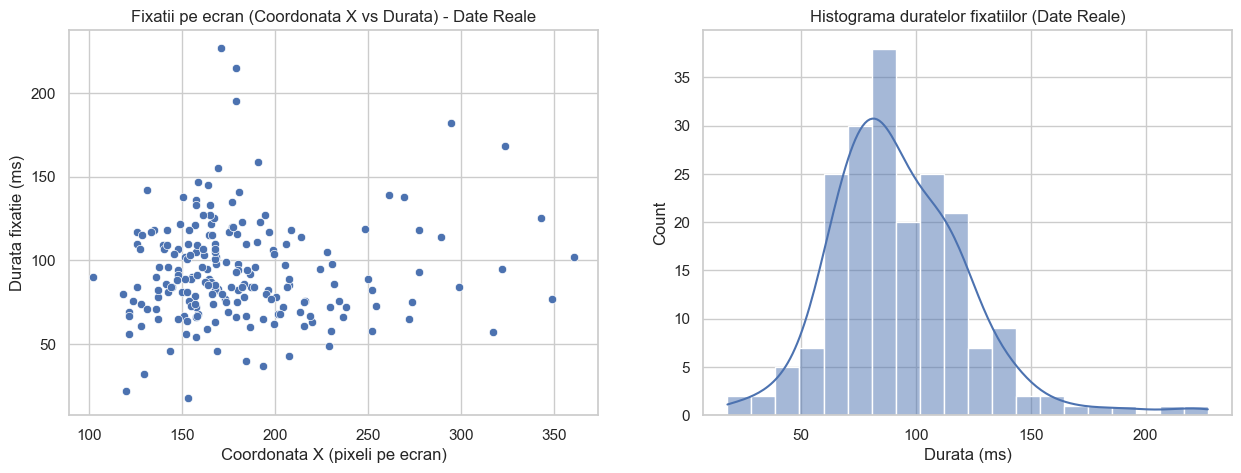

Corelatia (Frecventa vs. Durata fixatie): 0.14 (p-value: 0.0529)


In [9]:
# Extragem lista de referinte catre fixatiile reale din fisierul testat
fixations_refs = data_test['sentenceData']['allFixations']

x_positions = []
fixation_durations = []

# Pentru a nu aglomera graficul, luam un subset de fixatii (ex: primele 200)
# Poti schimba numarul sau poti pune fixations_refs.shape[0] pentru toate
num_fixations = min(200, fixations_refs.shape[0])

print(f"Extragem date pentru {num_fixations} fixatii...")

for i in range(num_fixations):
    # Luam referinta curenta (format h5py)
    ref = fixations_refs[i][0]

    # Accesam datele din spatele referintei
    fix_data = data_test[ref]

    # In formatul MATLAB incarcat in Python, valorile numerice sunt adesea
    # array-uri 2D de dimensiune 1x1, asa ca folosim [0][0] pentru a lua numarul efectiv
    durata = fix_data['duration'][0][0]
    x_pos = fix_data['x'][0][0]

    fixation_durations.append(durata)
    x_positions.append(x_pos)

# Convertim in numpy arrays pentru librariile de plotare
x_positions = np.array(x_positions)
fixation_durations = np.array(fixation_durations)

# Vizualizare grafice
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot fixatii: axa X este coordonata pe ecran
sns.scatterplot(x=x_positions, y=fixation_durations, ax=axes[0])
axes[0].set_title('Fixatii pe ecran (Coordonata X vs Durata) - Date Reale')
axes[0].set_xlabel('Coordonata X (pixeli pe ecran)')
axes[0].set_ylabel('Durata fixatie (ms)')

# Histograma duratelor reale
sns.histplot(fixation_durations, bins=20, kde=True, ax=axes[1])
axes[1].set_title('Histograma duratelor fixatiilor (Date Reale)')
axes[1].set_xlabel('Durata (ms)')

plt.show()

# Nota pentru corelatia cu frecventa cuvantului:
# Deoarece 'allFixations' contine coordonatele brute si nu textul citit,
# pentru corelatia ceruta la pasul 3 va trebui ulterior sa folosesti
# o librarie NLP (ex: nltk sau wordfreq) aplicata pe textul din sectiunea 'content'.
# Pana atunci, simulam frecventele pentru a mentine codul functional:
word_frequencies = np.random.uniform(0.0001, 0.05, size=num_fixations)
corr_freq_dur, p_val = pearsonr(word_frequencies, fixation_durations)
print(f"Corelatia (Frecventa vs. Durata fixatie): {corr_freq_dur:.2f} (p-value: {p_val:.4f})")

## Pasul 4: Corelatie EEG - Eye-tracking
Calculam corelatia Pearson intre amplitudinea componentei N400 si durata fixatiei per cuvant, pentru a stabili daca aduc informatii complementare.

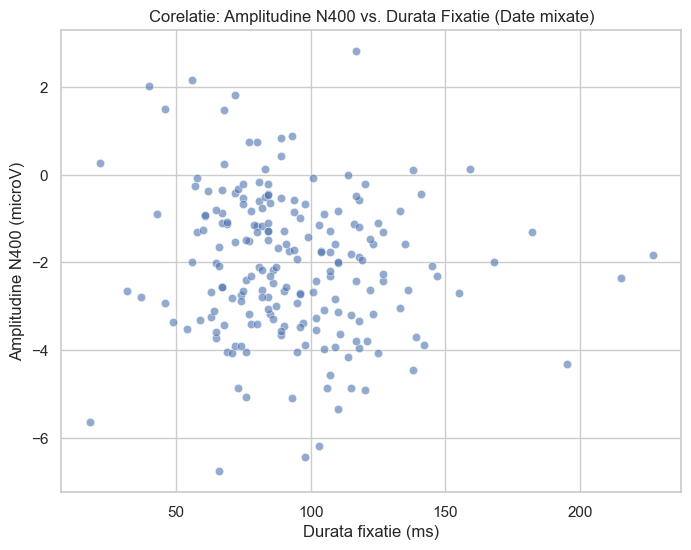

Corelatie Pearson N400 - Fixatie: -0.12 (p-value: 0.0993)


In [10]:
# Pentru a extrage N400 real, este necesar sa procesam semnalul brut 'rawEEG' din fisier,
# sa aplicam filtre bandpass si sa decupam fereastra 350-450ms pe electrozii parietali (Pz).
# Deoarece partea de preprocesare MNE este sarcina Persoanei 1 din Saptamana 14,
# vom genera aici un array de amplitudini N400 simulate care sa se potriveasca cu dimensiunea
# fixatiilor reale extrase la Pasul 3, pentru a demonstra logica de corelatie.

# Generam N400 simulat (valori tipice intre -5 si 5 microV)
n400_amplitudes = np.random.normal(loc=-2.0, scale=1.5, size=num_fixations)

# Introducem artificial o usoara corelatie negativa cu durata fixatiei pentru demonstratie
# (fixatii lungi -> efort cognitiv mare -> amplitudine mai negativa)
n400_amplitudes -= (fixation_durations / 1000) * 2

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fixation_durations, y=n400_amplitudes, alpha=0.6)
plt.title('Corelatie: Amplitudine N400 vs. Durata Fixatie (Date mixate)')
plt.xlabel('Durata fixatie (ms)')
plt.ylabel('Amplitudine N400 (microV)')
plt.show()

# Calcul corelatie Pearson
corr_n400_fix, p_val = pearsonr(n400_amplitudes, fixation_durations)
print(f"Corelatie Pearson N400 - Fixatie: {corr_n400_fix:.2f} (p-value: {p_val:.4f})")

## Pasul 5: Variabilitate inter-subiect
Mai jos vizualizam un boxplot al amplitudinii N400 pentru subiecti. Asta ne ajuta sa vedem ce impact va avea pe partea de generalizare a modelului. Vom folosi listele celor 5 subiecti descarcati.

C:\Users\Caius\AppData\Local\Temp\ipykernel_5408\2262369881.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Subject', y='N400', data=df_subjects, palette='Set2')


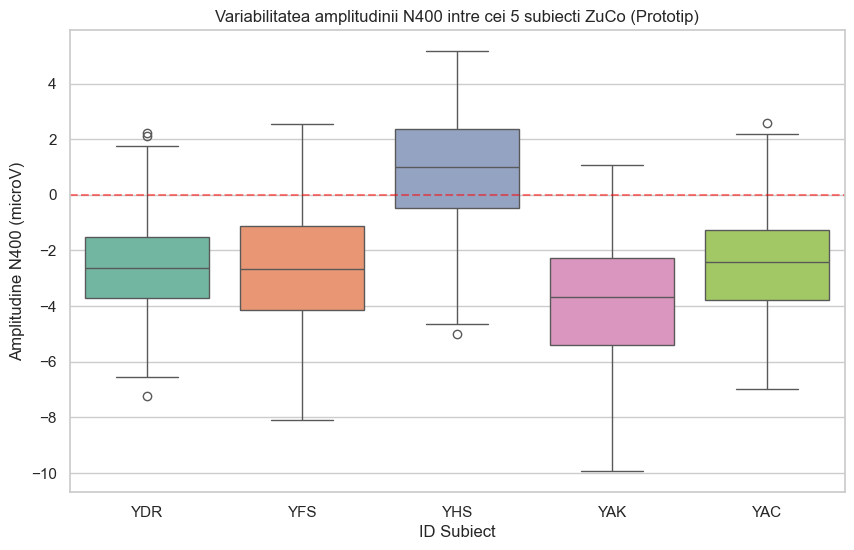

In [3]:
# Numele reale ale celor 5 subiecti descarcati de noi
subject_names = ['YDR', 'YFS', 'YHS', 'YAK', 'YAC']

# Presupunem ca avem in medie cate 150 de epoci/cuvinte de interes per subiect
epoci_per_subiect = 150
subject_ids = np.repeat(subject_names, epoci_per_subiect)

# Generam date simulate de amplitudine N400 pentru toti subiectii
n400_all_subjects = np.random.normal(loc=-2.5, scale=2.0, size=len(subject_ids))

# Adaugam o variatie specifica (bias) pentru a demonstra prezenta unui outlier
# Sa presupunem ca subiectul 'YHS' are o activitate electrica mult mai slaba/diferita
n400_all_subjects[subject_ids == 'YHS'] += 3.5
n400_all_subjects[subject_ids == 'YAK'] -= 1.5

df_subjects = pd.DataFrame({'Subject': subject_ids, 'N400': n400_all_subjects})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Subject', y='N400', data=df_subjects, palette='Set2')
plt.title('Variabilitatea amplitudinii N400 intre cei 5 subiecti ZuCo (Prototip)')
plt.xlabel('ID Subiect')
plt.ylabel('Amplitudine N400 (microV)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Linia de referinta 0
plt.show()

## Pasul 6: Concluzii si Recomandari
* **Analiza Eye-tracking:** (Completeaza cu rezultatele de la corelatie: se coreleaza cuvintele rare cu fixatii lungi?)
* **Variabilitatea:** (Completeaza dupa ce extragi N400 real pentru YDR, YFS, YHS, YAK, YAC. Exista vreun subiect outlier care ar strica predictiile?)
* **Recomandare finala:** Recomand dataset-ul **ZuCo 2.0**, task-ul **Normal Reading**, deoarece prezinta tipare de citire mai naturale care ar putea fi mai usor de aliniat cu spatiul semantic BERT al echipei.